In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [3]:
# Load the dataset
file_path = 'C:/Users/ASUS/OneDrive/Desktop/NoiseHandled1_MediTrack_Dataset.csv'
df = pd.read_csv(file_path)

In [4]:
# Prepare feature (X) and target (Y) variables
X = df[['CV','Buffer Percentage','Sales_LOESS_Date',
        'Log_Retail_Price', 'Log_Purchase_Price', 'Log_Mean_Sales', 'Log_Buffer_Stock', 'Month', 'Year',
        'Disease Category', 'Drug Category', 'Drug Name']]

Y = df[['Log_Sales']]

In [5]:
# Save 'Drug Name'& Disease Category before encoding
drug_names = X[['Drug Name']]
disease_categories = X[['Disease Category']]

In [6]:
# Convert categorical variables into numerical labels using One-Hot Encoding
X = pd.get_dummies(X, columns=['Disease Category', 'Drug Category', 'Drug Name'], drop_first=True)

In [7]:

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [8]:

# Convert to DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [9]:

# Set the model parameters
params = {
    'objective': 'reg:squarederror',  # Regression task
    'eval_metric': 'rmse',            # Evaluation metric: root mean square error
    'max_depth': 4,                   # Maximum tree depth
    'learning_rate': 0.03,             # Learning rate
    'colsample_bytree': 0.8,          # Column sampling rate
    'subsample': 0.9,                  # Subsample rate
    'reg_lambda': 10,                   # L2 regularization (Ridge)
    'reg_alpha': 2                      # L1 regularization (Lasso)
}

In [10]:
# Train the model by getting involved with cross validation
num_boost_round = 100  # Number of boosting rounds
cv_results = xgb.cv(
    params=params,
    dtrain=xgb.DMatrix(X, label=Y),  # Use the entire dataset for CV
    num_boost_round=num_boost_round,
    nfold=5,  # Number of folds in cross-validation
    early_stopping_rounds=10,  # Stop early if the performance doesn't improve
    as_pandas=True,  # Returns the results as a pandas DataFrame
    verbose_eval=True  # Print progress
)
# Display cross-validation results
print(cv_results)

[0]	train-rmse:2.04157+0.01010	test-rmse:2.04152+0.04021
[1]	train-rmse:1.99198+0.00973	test-rmse:1.99234+0.03921
[2]	train-rmse:1.94362+0.00940	test-rmse:1.94396+0.03851
[3]	train-rmse:1.89685+0.00909	test-rmse:1.89736+0.03773
[4]	train-rmse:1.85367+0.00901	test-rmse:1.85429+0.03689
[5]	train-rmse:1.80971+0.00879	test-rmse:1.81052+0.03600
[6]	train-rmse:1.76701+0.00845	test-rmse:1.76789+0.03515
[7]	train-rmse:1.72602+0.00825	test-rmse:1.72728+0.03409
[8]	train-rmse:1.68644+0.00789	test-rmse:1.68781+0.03322
[9]	train-rmse:1.64809+0.00764	test-rmse:1.64977+0.03246
[10]	train-rmse:1.61073+0.00737	test-rmse:1.61271+0.03153
[11]	train-rmse:1.57468+0.00713	test-rmse:1.57692+0.03054
[12]	train-rmse:1.53985+0.00692	test-rmse:1.54263+0.02959
[13]	train-rmse:1.50656+0.00666	test-rmse:1.50973+0.02887
[14]	train-rmse:1.47397+0.00670	test-rmse:1.47737+0.02758
[15]	train-rmse:1.44257+0.00645	test-rmse:1.44623+0.02673
[16]	train-rmse:1.41208+0.00643	test-rmse:1.41617+0.02586
[17]	train-rmse:1.38270+

In [11]:

#getting the best boosting round based on the evaluation metric
best_round = cv_results['test-rmse-mean'].idxmin()  # finding the best round with the minimum RMSE
print(f"Best boosting round: {best_round}")

Best boosting round: 99


In [12]:
# training the final model by using the best boosting round
model = xgb.train(
    params=params,
    dtrain=xgb.DMatrix(X, label=Y),
    num_boost_round=best_round  # Train with the optimal number of boosting rounds
)



# *Rolling Forecast Validation*

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [14]:
# Sort dataset by time
X['Month'] = df['Month']
X['Year'] = df['Year']
df = df.sort_values(by=['Year', 'Month'])

# Define features and target
features = ['CV', 'Buffer Percentage', 'Sales_LOESS_Date',
            'Log_Retail_Price', 'Log_Purchase_Price', 'Log_Mean_Sales', 'Log_Buffer_Stock', 'Month', 'Year']
target = 'Log_Sales'

rolling_rmse = []
rolling_mape = []
initial_train_size = 5  # first 5 months consideration for faster runtime
# Get unique months sorted
unique_months = sorted(df[['Year', 'Month']].drop_duplicates().values.tolist())

# Perform Rolling Forecast Validation correctly
for i in range(initial_train_size, len(unique_months) - 1):
    # Select training data (All rows belonging to full months up to month i)
    train_months = unique_months[:i]
    train_data = df[df[['Year', 'Month']].apply(tuple, axis=1).isin([tuple(m) for m in train_months])]

    # Select test data (All rows belonging to the next full month)
    next_month = unique_months[i]  # The next month to predict
    test_data = df[df[['Year', 'Month']].apply(tuple, axis=1) == tuple(next_month)]

    # Train XGBoost model
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
    xgb_model.fit(train_data[features], train_data[target])

    # Predict for all rows in the next full month
    pred = xgb_model.predict(test_data[features])

    # Calculate RMSE and MAPE for the full month
    rmse = np.sqrt(mean_squared_error(test_data[target], pred))
    rolling_rmse.append(rmse)
    # Calculate MAPE based on log-transformed values directly
    mape = mean_absolute_percentage_error(test_data[target].values, pred) * 100  # Keep MAPE in percentage
    rolling_mape.append(mape)

In [15]:
# Calculate Overall Accuracy Metrics
average_mape = np.mean(rolling_mape)  # MAPE is already in percentage
accuracy_mape_based = 100 - average_mape  # Estimated accuracy based on MAPE

average_rmse = np.mean(rolling_rmse)  # Log scale RMSE

# Calculate percentage of points with MAPE <= 20%
mape_below_5_percent = (np.sum(np.array(rolling_mape) <= 18) / len(rolling_mape)) * 100  # Corrected condition

print("\n--- Accuracy Summary ---")
print(f"Average MAPE: {average_mape:.4f}")
print(f"Average RMSE (Log Scale): {average_rmse:.4f}")
print(f"Estimated Accuracy (Based on MAPE): {accuracy_mape_based:.2f}%")
print(f"Percentage of Data Points with MAPE ≤ 20%: {mape_below_5_percent:.2f}%")



--- Accuracy Summary ---
Average MAPE: 9.4049
Average RMSE (Log Scale): 0.6875
Estimated Accuracy (Based on MAPE): 90.60%
Percentage of Data Points with MAPE ≤ 20%: 100.00%


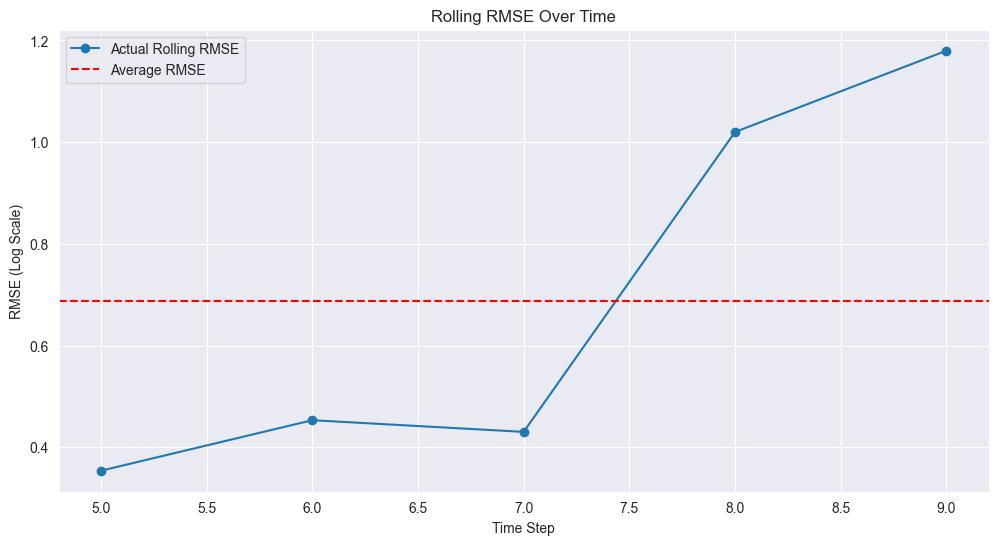

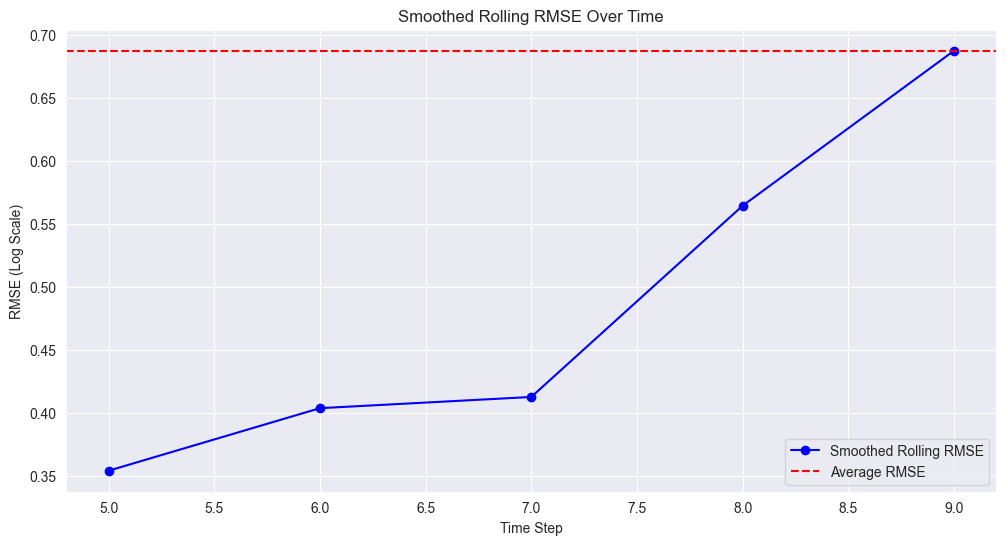

In [16]:
# Plot Actual Rolling RMSE
plt.figure(figsize=(12, 6))
plt.plot(range(initial_train_size, len(rolling_rmse) + initial_train_size), rolling_rmse, marker="o", label="Actual Rolling RMSE")
plt.axhline(y=average_rmse, color='r', linestyle='--', label="Average RMSE")  # Add horizontal line for avg RMSE
plt.xlabel("Time Step")
plt.ylabel("RMSE (Log Scale)")
plt.title("Rolling RMSE Over Time")
plt.legend()
plt.show()

# Plot Smoothed Rolling RMSE
smoothed_rmse = pd.Series(rolling_rmse).rolling(window=10, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(range(initial_train_size, len(rolling_rmse) + initial_train_size), smoothed_rmse, marker="o", color="blue", label="Smoothed Rolling RMSE")
plt.axhline(y=average_rmse, color='r', linestyle='--', label="Average RMSE")  # Add avg RMSE line
plt.xlabel("Time Step")
plt.ylabel("RMSE (Log Scale)")
plt.title("Smoothed Rolling RMSE Over Time")
plt.legend()
plt.show()

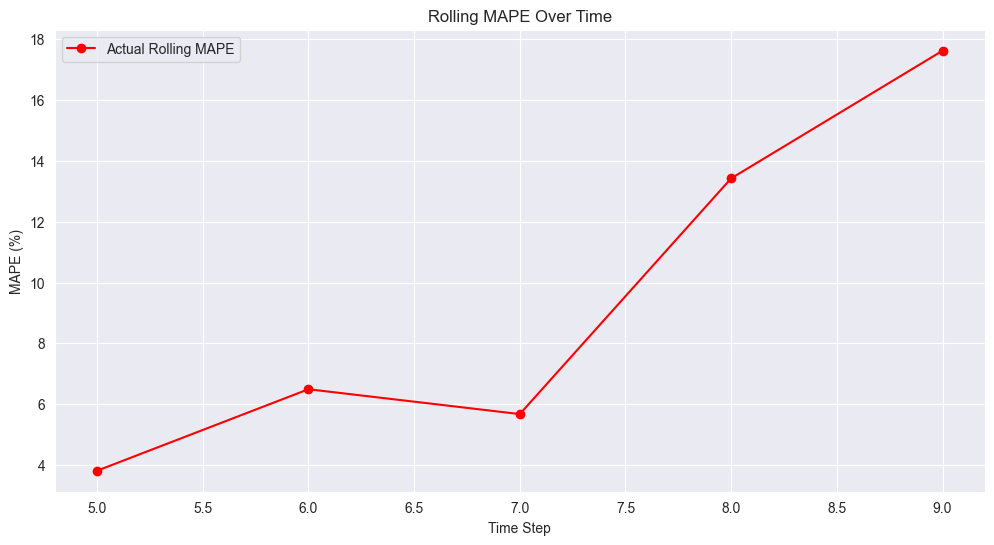

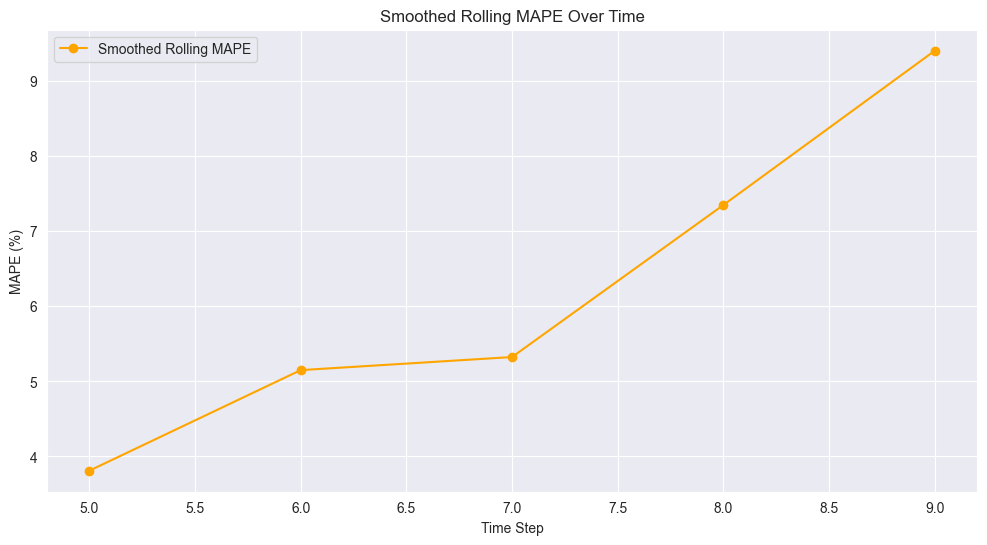

In [17]:

# Plot Actual Rolling MAPE
plt.figure(figsize=(12, 6))
plt.plot(range(initial_train_size, len(rolling_mape) + initial_train_size), rolling_mape, marker="o", color="red", label="Actual Rolling MAPE")
plt.xlabel("Time Step")
plt.ylabel("MAPE (%)")
plt.title("Rolling MAPE Over Time")
plt.legend()
plt.show()

# Plot Smoothed Rolling MAPE
smoothed_mape = pd.Series(rolling_mape).rolling(window=10, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(range(initial_train_size, len(rolling_mape) + initial_train_size), smoothed_mape, marker="o", color="orange", label="Smoothed Rolling MAPE")
plt.xlabel("Time Step")
plt.ylabel("MAPE (%)")
plt.title("Smoothed Rolling MAPE Over Time")
plt.legend()
plt.show()


In [18]:
# saving test dataset for future predictions
X_test_future=X_test.copy()



In [19]:
import numpy as np
# loop XGBooster for 6 months predictions
future_results=pd.DataFrame()
for month in range(1,7):
  # Simulate the Date using Month and Year
  X_test_future['Date'] = pd.to_datetime(X_test_future[['Year', 'Month']].assign(Day=1))
  # Handle Month and Year updation
  X_test_future['Month']+=1
  X_test_future['Year']+= (X_test_future['Month'] > 12).astype(int) # handle Year overflow situations
  X_test_future['Month']=X_test_future['Month'] % 12 # Reset Months for exceeding 12 situations
  X_test_future['Month'].replace(0, 12, inplace=True)
  # Update the Date column
  X_test_future['Date'] = pd.to_datetime(X_test_future[['Year', 'Month']].assign(Day=1))

  X_test_future=X_test_future.drop(columns=['Date']) # Drop Month and Year from Original dataset.
  # prepare the dataset for predictions
  dtest_future = xgb.DMatrix(X_test_future)
  # Predict the next month's sales (in log scale)
  log_predictions_future = model.predict(dtest_future)

  # Convert log predictions back to original scale
  predictions_future = np.exp(log_predictions_future)


  # Dynamically update Mean Sales
  X_test_future ['Log_Mean_Sales'] = np.log(
    (np.exp(X_test_future['Log_Mean_Sales']) * month + predictions_future) / (month + 1)
    )
  # Update Buffer Stock dynamically
  X_test_future['Log_Buffer_Stock'] = np.log(predictions_future *np.exp( X_test_future['Log_Buffer_Stock']))



  future_Month_Results=pd.DataFrame({
          'Disease Category': disease_categories.iloc[X_test_future.index]['Disease Category'],
          'Drug Name': drug_names.iloc[X_test_future.index]['Drug Name'],
          'Month': [month] * len(predictions_future),
          'Predicted Sales': predictions_future

      })

     # Concatenate instead of append
  future_results = pd.concat([future_results, future_Month_Results], ignore_index=True)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11960\1041444783.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_future['Month'].replace(0, 12, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11960\1041444783.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [20]:
print(future_results.head())

  Disease Category            Drug Name  Month  Predicted Sales
0         Diabetes  GLIPIZIDE (USV) 5MG      1        47.635059
1   Cardiovascular          TROKAN 75MG      1      1048.984985
2      Cholesterol        X-PLENDED 5MG      1        96.731857
3         Diabetes         GLIX 40 80MG      1       182.337616
4      Cholesterol          ATOGEN 10MG      1       709.853577


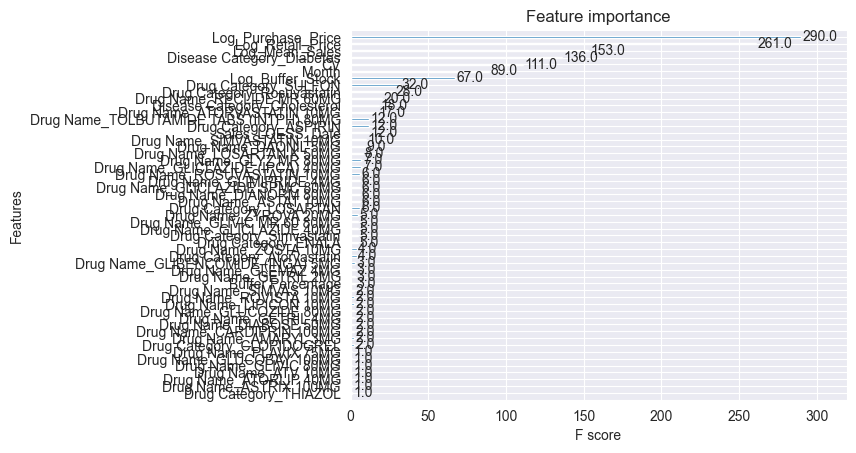

In [27]:
# Getting feature importance scores from the trained model
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()


# R^2 and Coefficient of Variance Determination

In [28]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, predictions_future)
print(f"R²: {r2}")

R²: -1836636.75


In [29]:
import numpy as np

# Calculate Coefficient of Variation (CV)
cv =( np.std(predictions_future) / np.mean(predictions_future) )* 100
print(f"Coefficient of Variation (CV): {cv}%")

Coefficient of Variation (CV): 164.69784545898438%


In [30]:
# Pivot the DataFrame so each drug has predictions in a single row
pivot_results = future_results.pivot_table(
    index=['Disease Category', 'Drug Name'],
    columns='Month',
    values='Predicted Sales'
).reset_index()

#Enhancing readability by renaming for all Predictions
pivot_results.columns = ['Disease Category', 'Drug Name', 'Prediction 1', 'Prediction 2', 'Prediction 3', 'Prediction 4', 'Prediction 5', 'Prediction 6']


In [31]:
output_file = "C:/Users/ASUS/OneDrive/Desktop/Medicine prediction XGBooster.xlsx"
pivot_results.to_excel(output_file, index=False)

print(f"Predictions saved successfully to: {output_file}")

Predictions saved successfully to: C:/Users/ASUS/OneDrive/Desktop/Medicine prediction XGBooster.xlsx


In [32]:
import joblib

# xgb_model is your trained XGBoost model
joblib.dump(xgb_model, "../PythonProject/FlaskProject/xgboost_model.pkl")
print("Model saved as xgboost_model.pkl")


Model saved as xgboost_model.pkl
